In [29]:
%load_ext autoreload
%autoreload 2
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import scipy
from scripts.utils import getC,getCol,getRow,getMu, init_dataset, get_hist, get_scatters, compute_Sb_Sw, init_dataset_for_binary_classification,split_db_2to1
from scripts.dimensionalityreduction import train_PCA,train_LDA,apply_PCA,apply_LDA
from scripts.pca_lda_classifiers import LDA_classifier,LDA_with_PCA_classifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
D,L,classes,features=init_dataset()

Le classi sono : ['setosa' 'versicolor' 'virginica'] e le features :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
mu=getMu(D)
C=getC(D)
print(f"La media è {mu} e la matrice di Covarianza è: {C}")

La media è [5.84333333 3.05733333 3.758      1.19933333] e la matrice di Covarianza è: [[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


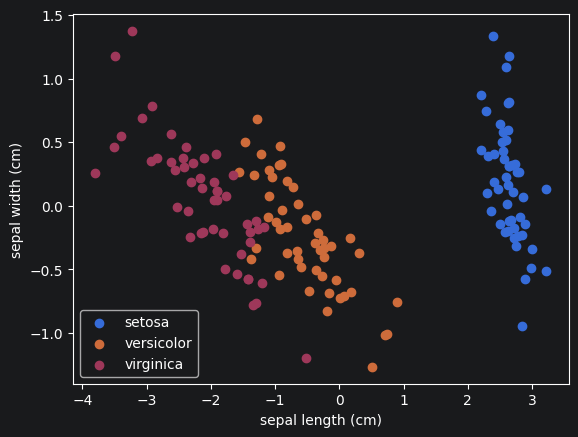

In [7]:
m=2
P,mu=train_PCA(D,m)
DP=apply_PCA(D,P,mu)

get_scatters(DP,L,features,classes)



In [131]:
# Salvataggio del grafico PCA
import os
output_dir = '../images'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(10, 8))
plt.xlabel("First Principal Component", fontsize=12)
plt.ylabel("Second Principal Component", fontsize=12)
plt.title("PCA Projection - All Classes", fontsize=14)

for c in range(len(classes)):
    mask = L==c
    DP_class = DP[:, mask]
    plt.scatter(DP_class[0, :], DP_class[1, :], label=classes[c], alpha=0.6, s=50)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'pca_projection.png'), dpi=150, bbox_inches='tight')
plt.close()

print("PCA projection saved to images/pca_projection.png")

PCA projection saved to images/pca_projection.png


In [12]:
Sb,Sw=compute_Sb_Sw(D,L)
print(f"La between class covariance matrix è {Sb} \n La within class covariance matrix è{Sw}")




La between class covariance matrix è [[ 0.42141422 -0.13301778  1.101656    0.47519556]
 [-0.13301778  0.07563289 -0.38159733 -0.15288444]
 [ 1.101656   -0.38159733  2.91401867  1.24516   ]
 [ 0.47519556 -0.15288444  1.24516     0.53608889]] 
 La within class covariance matrix è[[0.259708   0.09086667 0.164164   0.03763333]
 [0.09086667 0.11308    0.05413867 0.032056  ]
 [0.164164   0.05413867 0.181484   0.041812  ]
 [0.03763333 0.032056   0.041812   0.041044  ]]


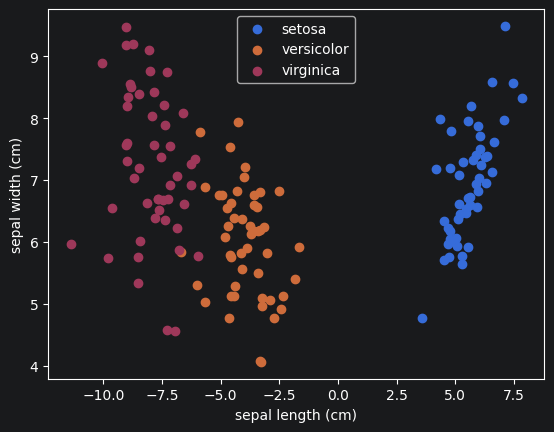

In [13]:
W=train_LDA(D,L,m)
DP=apply_LDA(D,W)
get_scatters(DP,L,features,classes)



In [132]:
# Salvataggio del grafico LDA
plt.figure(figsize=(10, 8))
plt.xlabel("First LDA Component", fontsize=12)
plt.ylabel("Second LDA Component", fontsize=12)
plt.title("LDA Projection - All Classes", fontsize=14)

for c in range(len(classes)):
    mask = L==c
    DP_class = DP[:, mask]
    plt.scatter(DP_class[0, :], DP_class[1, :], label=classes[c], alpha=0.6, s=50)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lda_projection.png'), dpi=150, bbox_inches='tight')
plt.close()

print("LDA projection saved to images/lda_projection.png")

LDA projection saved to images/lda_projection.png


In [30]:
DB,LB=init_dataset_for_binary_classification()

In [31]:
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(DB, LB)


In [32]:
LDA_classifier(DTR,LTR,DVAL,LVAL)

Threshold: 4.078616922547409
Mean Versicolor (class 1): 2.1314931222050717 Mean Virginica (class 2): 6.025740722889748
Labels:      [1 2 1 2 1 1 1 2 2 2 1 2 2 2 1 1 2 1 1 2 2 1 2 2 2 1 1 2 1 2 2 2 1 1]
Predictions: [1 2 1 2 1 1 1 2 2 2 2 2 2 2 1 1 2 1 1 2 2 1 2 2 2 1 1 1 1 2 2 2 1 1]
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%


In [133]:
# Visualizzazione e salvataggio degli istogrammi per il classificatore LDA
unique_classes = np.unique(LTR)
W_vis=train_LDA(DTR,LTR,1)
DTR_lda_vis=apply_LDA(DTR,W_vis)
DVAL_lda_vis = W_vis.T @ DVAL

# Correggi l'orientamento
mean_versicolor = DTR_lda_vis[0, LTR==1].mean()
mean_virginica = DTR_lda_vis[0, LTR==2].mean()
if mean_virginica < mean_versicolor:
    W_vis = -W_vis
    DTR_lda_vis = W_vis.T @ DTR
    DVAL_lda_vis = W_vis.T @ DVAL

# Istogramma Training Set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(DTR_lda_vis[0, LTR==1], bins=5, density=True, alpha=0.6, label='Versicolor', color='orange')
ax1.hist(DTR_lda_vis[0, LTR==2], bins=5, density=True, alpha=0.6, label='Virginica', color='green')
ax1.set_xlabel('LDA Projection', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Model Training Set (DTR, LTR)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Istogramma Validation Set
ax2.hist(DVAL_lda_vis[0, LVAL==1], bins=5, density=True, alpha=0.6, label='Versicolor', color='orange')
ax2.hist(DVAL_lda_vis[0, LVAL==2], bins=5, density=True, alpha=0.6, label='Virginica', color='green')
ax2.set_xlabel('LDA Projection', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Validation Set (DVAL, LVAL)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lda_binary_histograms.png'), dpi=150, bbox_inches='tight')
plt.close()

print("LDA binary classification histograms saved to images/lda_binary_histograms.png")

LDA binary classification histograms saved to images/lda_binary_histograms.png


In [9]:
for m in range(1, 5):  # m da 1 a 4 (escludendo 0 e 4 secondo le specifiche)
    LDA_with_PCA_classifier(DTR,LTR,DVAL,LVAL,m)



--- PCA with m=1 dimensions ---
Threshold: 0.030654114727430737
Mean Versicolor (class 1): -0.9809316712777132 Mean Virginica (class 2): 1.0422399007325747
Number of errors: 4 (out of 34 samples)
Error rate: 11.8%

--- PCA with m=2 dimensions ---
Threshold: 0.05345076035590479
Mean Versicolor (class 1): -1.7104243313888736 Mean Virginica (class 2): 1.8173258521006832
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%

--- PCA with m=3 dimensions ---
Threshold: 0.05421910011245212
Mean Versicolor (class 1): -1.7350112035983853 Mean Virginica (class 2): 1.8434494038232896
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%

--- PCA with m=4 dimensions ---
Threshold: 0.05900375152552695
Mean Versicolor (class 1): -1.8881200488168115 Mean Virginica (class 2): 2.0061275518678654
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%
